## Multivariate Analysis

In [1]:
# Import libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os, sys 

# System configuration 
sys.path.append(os.path.abspath(".."))

## Data Ingestion

In [2]:
# Import functionality for data ingestion
from scripts.data_collection import DataLoader

In [3]:
# Load the dataset 
csv_loader = DataLoader(folder="processed")
dataset = csv_loader.collect(filename="laptop_price_ds_v5.csv")
dataset 

# Load the feature dataset 


,Brand,Processor_brand,Processor_name,Ram_gb,Ssd,Hdd,Os,Graphic_card_gb,Weight,Touchscreen,Msoffice,Price,Number of ratings,Number of reviews
0,ASUS,Intel,Core i3,4,512,1024,Windows,0,Casual,0,0,34649,3,0
1,Lenovo,Intel,Core i3,4,512,1024,Windows,0,Casual,0,0,38999,65,5
2,Lenovo,Intel,Core i3,4,512,1024,Windows,0,Casual,0,0,39999,8,1
3,ASUS,Intel,Core i5,8,512,0,Windows,2,Casual,0,0,69990,0,0
4,ASUS,Intel,Celeron Dual,4,512,512,Windows,0,Casual,0,0,26990,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,ASUS,AMD,Ryzen 9,4,1024,0,Windows,0,Casual,0,0,135990,0,0
797,ASUS,AMD,Ryzen 9,4,1024,0,Windows,0,Casual,0,0,144990,0,0
798,ASUS,AMD,Ryzen 9,4,1024,0,Windows,4,Casual,0,0,149990,0,0
799,ASUS,AMD,Ryzen 9,4,1024,0,Windows,4,Casual,0,0,142990,0,0


## Correlation Analysis

In [4]:
# Import functionalities to do correlation analysis
from scripts.feature_transform_utils import create_plot_distribution
from scripts.data_analysis_utils import correlation_analysis

Correlation Analysis 1: Entire Dataset

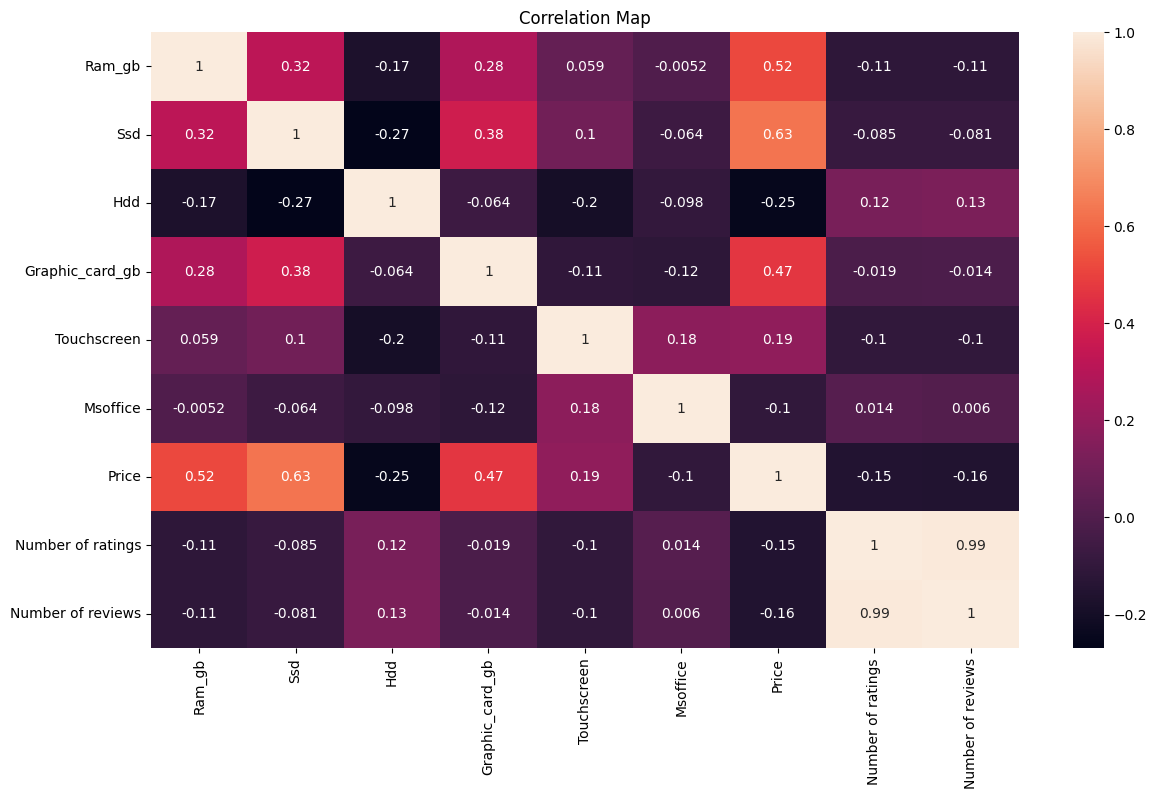

In [5]:
# Select the numeric features 
num_dataset = dataset.select_dtypes([int, float])
num_dataset

# Create a correlation analysis 
correlation_analysis(num_dataset)

Correlation Analysis 2: Features vs Price 

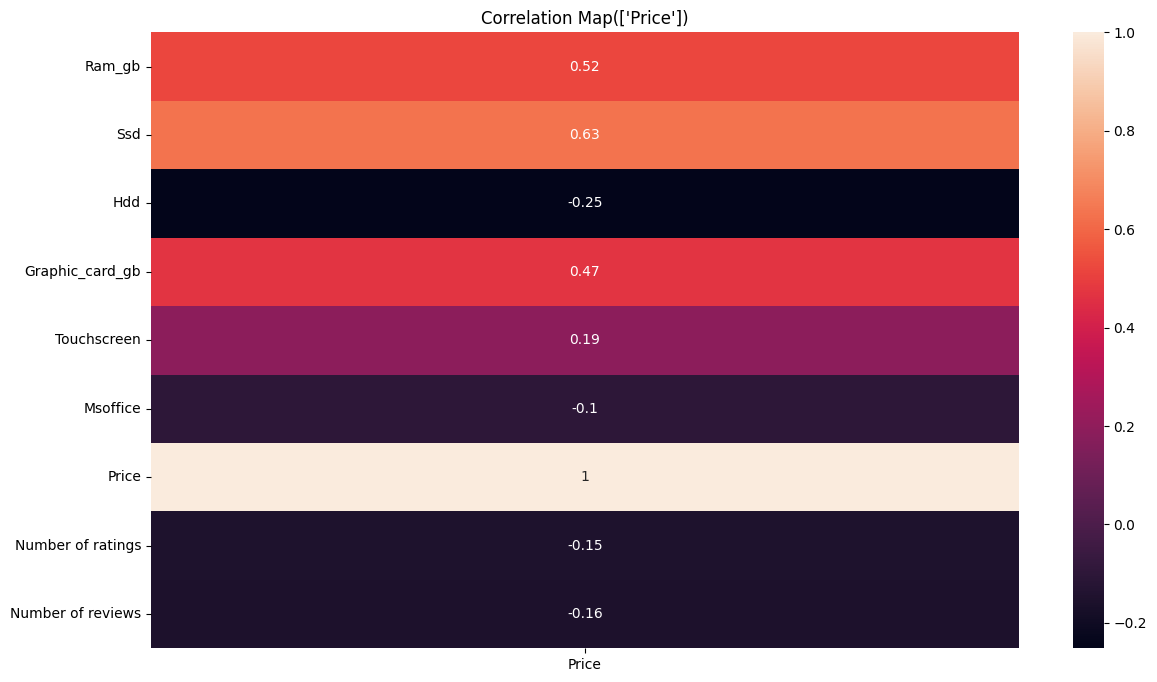

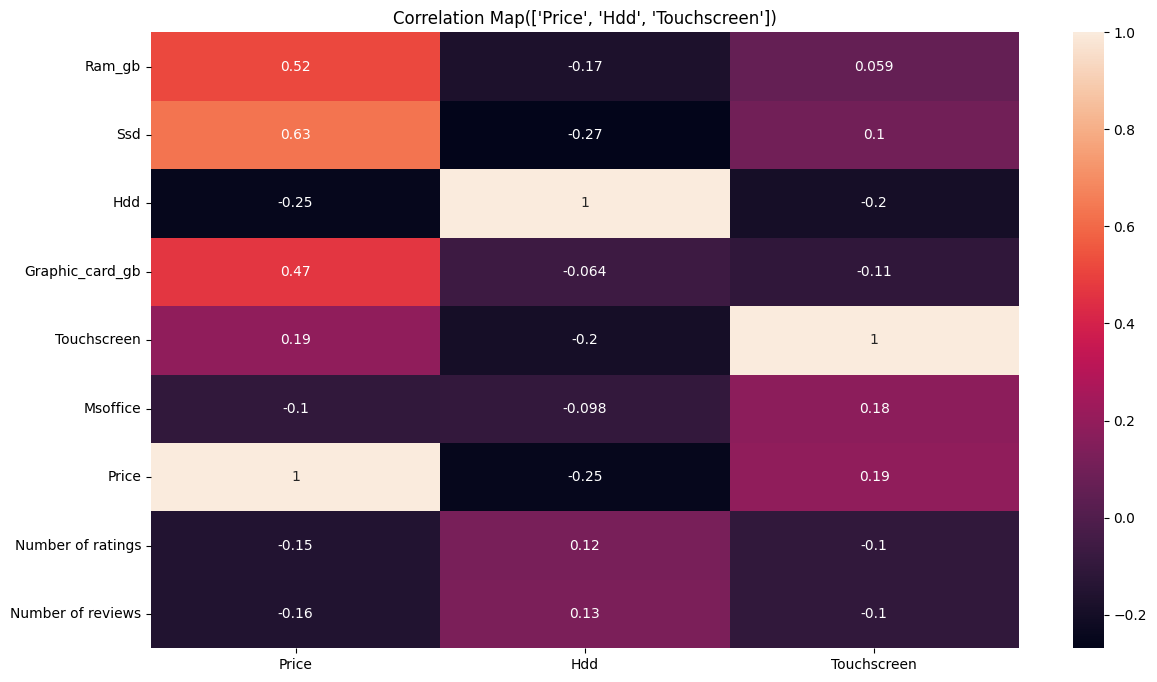

In [6]:
# Correlation analysis 2: features vs Price
correlation_analysis(num_dataset, features=["Price"])

# Correlation analysis: Price vs Hdd, Touchscreen
correlation_analysis(num_dataset, features=["Price", "Hdd", "Touchscreen"])

### Insight on Correlation Analysis

The features that show strong relationship with the price feature are: 
- Ram GB: 52% 
- SSD capacity: 63%
- HDD capacity: -25%
- Graphic_Card_GB: 47%
- Touchscreen: 19%

All the rest are presenting a weak relationship with price. 

## Feature Selection

In [7]:
# Select the features 
sel_features = ['Ram_gb', 'Ssd', 'Hdd', 'Graphic_card_gb', 'Touchscreen', 
        # 'Msoffice',
       'Price', 
       #'Number of ratings', 'Number of reviews'
       ]

sel_feature_ds = num_dataset[sel_features]
sel_feature_ds

,Ram_gb,Ssd,Hdd,Graphic_card_gb,Touchscreen,Price
0,4,512,1024,0,0,34649
1,4,512,1024,0,0,38999
2,4,512,1024,0,0,39999
3,8,512,0,2,0,69990
4,4,512,512,0,0,26990
...,...,...,...,...,...,...
796,4,1024,0,0,0,135990
797,4,1024,0,0,0,144990
798,4,1024,0,4,0,149990
799,4,1024,0,4,0,142990


In [8]:
# Create a dataloader to save the new dataset into a new folder
data_saver = DataLoader(folder="feature_sel_data")
data_saver.save(store_package=(f"num_feature_ds", sel_feature_ds), folder="numeric", version_nr=1)

Dataset num_feature_ds_v1.csv has been stored succesfully in path loc. C:\Development\03_ML_Engineering\Projects\ML_Projects\Laptop_Price_Prediction\data\feature_sel_data\numeric
